In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!ls /content/drive/MyDrive/ravdess_speech/ | head -5

Actor_01
Actor_02
Actor_03
Actor_04
Actor_05


In [4]:
!ls -lh ravdess.zip

ls: cannot access 'ravdess.zip': No such file or directory


In [5]:
import os
os.environ['KAGGLE_USERNAME'] = 'sabihametlo'
os.environ['KAGGLE_KEY'] = 'KAGGLE_KEY'

In [6]:
!kaggle datasets download -d uwrfkaggler/ravdess-emotional-speech-audio

Dataset URL: https://www.kaggle.com/datasets/uwrfkaggler/ravdess-emotional-speech-audio
License(s): CC-BY-NC-SA-4.0
100% 429M/429M [00:02<00:00, 192MB/s]



In [7]:
!ls -lh ravdess-emotional-speech-audio.zip

-rw-r--r-- 1 root root 430M Oct 17  2019 ravdess-emotional-speech-audio.zip


In [8]:
!unzip -q ravdess-emotional-speech-audio.zip -d ravdess_speech

In [9]:
!cp -r ravdess_speech /content/drive/MyDrive/

In [10]:
!ls /content/drive/MyDrive/ravdess_speech/Actor_01 | head -5

03-01-01-01-01-01-01.wav
03-01-01-01-01-02-01.wav
03-01-01-01-02-01-01.wav
03-01-01-01-02-02-01.wav
03-01-02-01-01-01-01.wav


Sample rate: 48000
Waveform shape: (158558,)
Duration (seconds): 3.3032916666666665


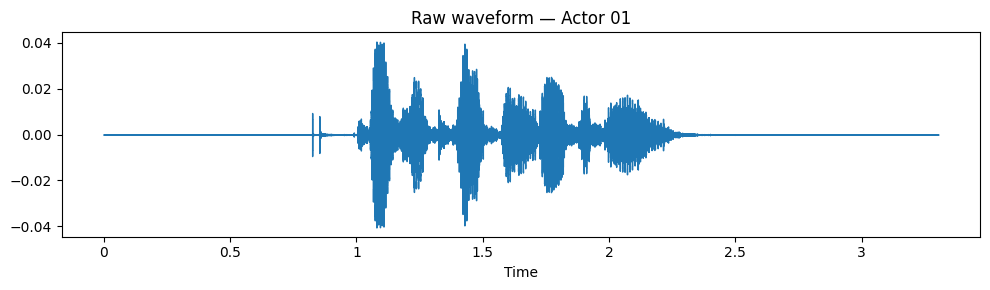

Emotion: neutral


In [11]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import os

# Step A — one real file from Actor_01
file_path = "/content/drive/MyDrive/ravdess_speech/Actor_01/03-01-01-01-01-01-01.wav"

# Step B — load with native sample rate
waveform, sample_rate = librosa.load(file_path, sr=None)

# Step C — sanity check
print("Sample rate:", sample_rate)
print("Waveform shape:", waveform.shape)
print("Duration (seconds):", waveform.shape[0] / sample_rate)

# Step D — plot waveform
plt.figure(figsize=(10, 3))
librosa.display.waveshow(waveform, sr=sample_rate)
plt.title("Raw waveform — Actor 01")
plt.tight_layout()
plt.show()

# Step E — parse emotion from filename
emotion_map = {
    "01": "neutral", "02": "calm", "03": "happy", "04": "sad",
    "05": "angry", "06": "fearful", "07": "disgust", "08": "surprised"
}

def get_emotion_from_filename(filepath):
    filename = os.path.basename(filepath)   # strips the folder path
    parts = filename.split("-")             # splits on dash
    return emotion_map[parts[2]]            # index 2 = emotion field

print("Emotion:", get_emotion_from_filename(file_path))

In [12]:
import os
import librosa
import pandas as pd
import matplotlib.pyplot as plt

emotion_map = {
    "01": "neutral", "02": "calm", "03": "happy", "04": "sad",
    "05": "angry", "06": "fearful", "07": "disgust", "08": "surprised"
}

data_dir = "/content/drive/MyDrive/ravdess_speech"
records = []

for actor_folder in sorted(os.listdir(data_dir)):
    actor_path = os.path.join(data_dir, actor_folder)
    if not os.path.isdir(actor_path):
        continue
    for fname in os.listdir(actor_path):
        if not fname.endswith(".wav"):
            continue
        parts = fname.split("-")
        emotion = emotion_map[parts[2]]
        fpath = os.path.join(actor_path, fname)
        duration = librosa.get_duration(path=fpath)
        records.append({"file": fname, "emotion": emotion, "duration": duration})

df = pd.DataFrame(records)
print(df.shape)
print(df["emotion"].value_counts())
print(df["duration"].describe())

(1440, 3)
emotion
calm         192
happy        192
sad          192
angry        192
disgust      192
fearful      192
surprised    192
neutral       96
Name: count, dtype: int64
count    1440.000000
mean        3.700665
std         0.336676
min         2.936271
25%         3.470146
50%         3.670333
75%         3.870542
max         5.271937
Name: duration, dtype: float64


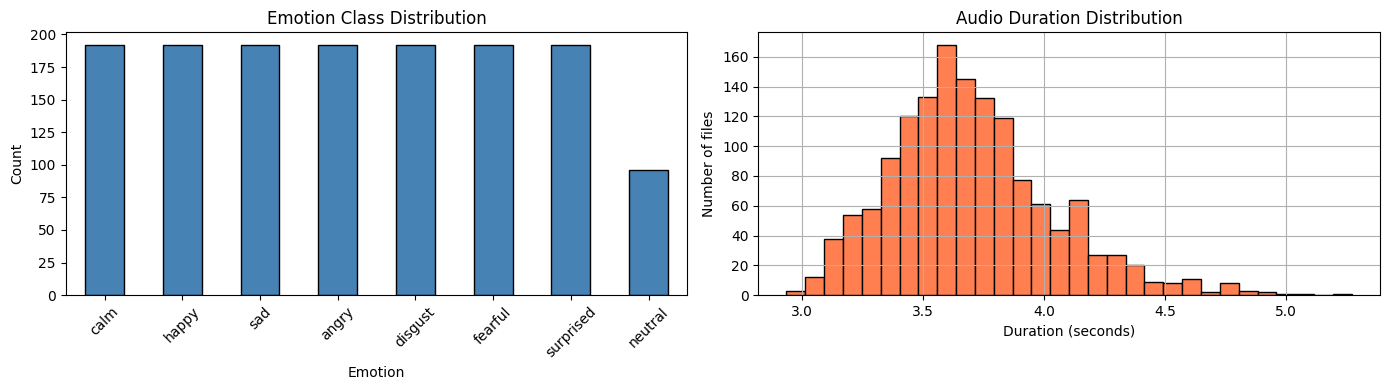

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Plot 1 — class distribution
df["emotion"].value_counts().plot(kind="bar", ax=ax1, color="steelblue", edgecolor="black")
ax1.set_title("Emotion Class Distribution")
ax1.set_xlabel("Emotion")
ax1.set_ylabel("Count")
ax1.tick_params(axis='x', rotation=45)

# Plot 2 — duration spread
df["duration"].hist(bins=30, ax=ax2, color="coral", edgecolor="black")
ax2.set_title("Audio Duration Distribution")
ax2.set_xlabel("Duration (seconds)")
ax2.set_ylabel("Number of files")

plt.tight_layout()
plt.show()

MFCC shape: (40, 130)


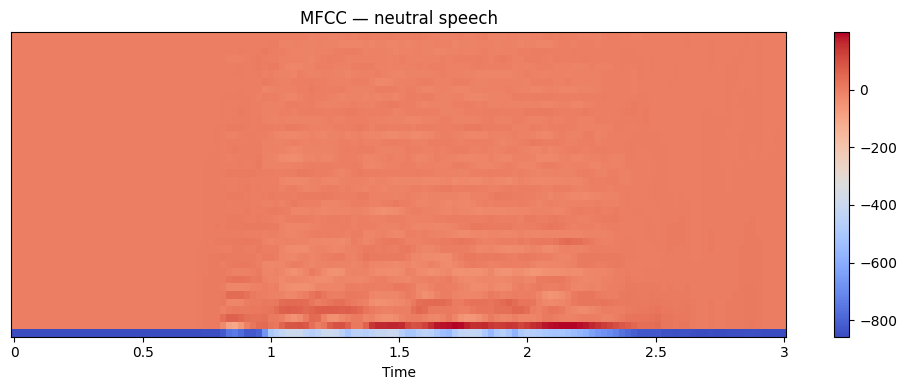

In [14]:
import numpy as np
import librosa
def extract_mfcc(filepath, sr=22050, duration=3, n_mfcc=40):
    # Step 1 — load and resample to sr, fixed duration
    # hint: librosa.load has an offset and duration parameter
    waveform, _ = librosa.load(filepath, sr=22050, duration=3)

    # Step 2 — pad with zeros if waveform is shorter than 3 seconds
    # hint: target length = sr * duration
    target_length = 66150
    if len(waveform) < target_length:
        waveform = np.pad(waveform, (0, target_length - len(waveform)))

    # Step 3 — extract MFCCs
    mfcc = librosa.feature.mfcc(y=waveform, sr=sr, n_mfcc=40)

    return mfcc
# Test on one file
mfcc = extract_mfcc("/content/drive/MyDrive/ravdess_speech/Actor_01/03-01-01-01-01-01-01.wav")
print("MFCC shape:", mfcc.shape)
# Visualize it
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
librosa.display.specshow(mfcc, x_axis='time')
plt.colorbar()
plt.title("MFCC — neutral speech")
plt.tight_layout()
plt.show()

In [15]:
import numpy as np
import os

def build_dataset(data_dir, sr=22050, duration=3, n_mfcc=40):
    X = []
    y = []

    emotion_map = {
        "01": "neutral", "02": "calm", "03": "happy", "04": "sad",
        "05": "angry", "06": "fearful", "07": "disgust", "08": "surprised"
    }

    for actor_folder in sorted(os.listdir(data_dir)):
        actor_path = os.path.join(data_dir, actor_folder)
        if not os.path.isdir(actor_path):
            continue

        for fname in os.listdir(actor_path):
            if not fname.endswith(".wav"):
                continue

            filepath = os.path.join(actor_path, fname)
            parts = fname.split("-")
            emotion = emotion_map[parts[2]]
            mfcc = extract_mfcc(filepath)
            X.append(mfcc)
            y.append(emotion)

    return np.array(X), np.array(y)

data_dir = "/content/drive/MyDrive/ravdess_speech"
X, y = build_dataset(data_dir)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Sample labels:", y[:5])

X shape: (1440, 40, 130)
y shape: (1440,)
Sample labels: ['neutral' 'calm' 'calm' 'neutral' 'calm']


In [16]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
import numpy as np

# Step 1
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Step 2
y_onehot = to_categorical(y_encoded, num_classes=8)

# Step 3
X_reshaped = X.reshape(1440, 40, 130, 1)

# Step 4
X_train, X_test, y_train, y_test = train_test_split(
    X_reshaped, y_onehot,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# Step 5
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("Classes:", le.classes_)

X_train: (1152, 40, 130, 1)
X_test: (288, 40, 130, 1)
y_train: (1152, 8)
Classes: ['angry' 'calm' 'disgust' 'fearful' 'happy' 'neutral' 'sad' 'surprised']


In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

def build_cnn(input_shape, num_classes):
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.25),

        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.25),

        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(8, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

input_shape = (40, 130, 1)
model = build_cnn(input_shape, num_classes=8)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 40, 130, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 40, 130, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 20, 65, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20, 65, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 20, 65, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 20, 65, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 10, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 20480)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,621,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,641,800 (10.08 MB)

 Trainable params: 2,641,608 (10.08 MB)

 Non-trainable params: 192 (768.00 B)

In [18]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - accuracy: 0.1450 - loss: 4.2231 - val_accuracy: 0.2049 - val_loss: 2.0238 - learning_rate: 0.0010
Epoch 2/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.1719 - loss: 2.0344 - val_accuracy: 0.2326 - val_loss: 2.0075 - learning_rate: 0.0010
Epoch 3/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.1806 - loss: 2.0437 - val_accuracy: 0.2326 - val_loss: 1.9863 - learning_rate: 0.0010
Epoch 4/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.1780 - loss: 2.0504 - val_accuracy: 0.2014 - val_loss: 2.0287 - learning_rate: 0.0010
Epoch 5/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.1632 - loss: 2.0403 - val_accuracy: 0.1910 - val_loss: 2.0375 - learning_rate: 0.0010
Epoch 6/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.1736 - loss: 2.0229 - val_accuracy: 0.2188 - val_loss: 1.9931 - learning_rate: 0.0010
Epoch 7/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.1840 - loss: 1.9963 - val_ac

In [19]:
# Normalize X to zero mean, unit variance
mean = X_train.mean()
std = X_train.std()

X_train_norm = (X_train - mean) / std
X_test_norm = (X_test - mean) / std

print("Before normalization — min:", X_train.min(), "max:", X_train.max())
print("After normalization — min:", X_train_norm.min().round(2), "max:", X_train_norm.max().round(2))

Before normalization — min: -1087.2701 max: 238.0774
After normalization — min: -11.38 max: 2.67


In [20]:
# Rebuild fresh model (resets weights)
model = build_cnn(input_shape=(40, 130, 1), num_classes=8)

history = model.fit(
    X_train_norm, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test_norm, y_test),
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 7s 39ms/step - accuracy: 0.1432 - loss: 3.7660 - val_accuracy: 0.1354 - val_loss: 2.0723 - learning_rate: 0.0010
Epoch 2/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.1536 - loss: 2.0511 - val_accuracy: 0.1354 - val_loss: 2.0934 - learning_rate: 0.0010
Epoch 3/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.1884 - loss: 2.0313 - val_accuracy: 0.1354 - val_loss: 2.1316 - learning_rate: 0.0010
Epoch 4/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.1806 - loss: 2.0485 - val_accuracy: 0.1354 - val_loss: 2.1658 - learning_rate: 0.0010
Epoch 5/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.1918 - loss: 2.0087 - val_accuracy: 0.1354 - val_loss: 2.1655 - learning_rate: 0.0010
Epoch 6/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.1979 - loss: 1.9676 - val_accuracy: 0.1354 - val_loss: 2.1454 - learning_rate: 5.0000e-04
Epoch 7/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.2049 - loss: 1.9447 - val

In [21]:
# Clear session completely
import tensorflow as tf
tf.keras.backend.clear_session()

# Recheck GPU
print("GPU available:", tf.config.list_physical_devices('GPU'))

# Rebuild model fresh
model = build_cnn(input_shape=(40, 130, 1), num_classes=8)

# Fresh callbacks — important, old ones carry state
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

# Train with normalized data
history = model.fit(
    X_train_norm, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test_norm, y_test),
    callbacks=[early_stop, reduce_lr]
)

GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Epoch 1/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - accuracy: 0.1276 - loss: 3.7514 - val_accuracy: 0.1424 - val_loss: 2.0799 - learning_rate: 0.0010
Epoch 2/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.1406 - loss: 2.0764 - val_accuracy: 0.1458 - val_loss: 2.0820 - learning_rate: 0.0010
Epoch 3/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.1337 - loss: 2.0761 - val_accuracy: 0.1354 - val_loss: 2.0986 - learning_rate: 0.0010
Epoch 4/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.1345 - loss: 2.0746 - val_accuracy: 0.1354 - val_loss: 2.1139 - learning_rate: 0.0010
Epoch 5/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.1363 - loss: 2.0711 - val_accuracy: 0.1354 - val_loss: 2.1180 - learning_rate: 0.0010
Epoch 6/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.1450 - loss: 2.0723 - val_accuracy: 0.1458 - val_loss: 2.0957 - learning_rate: 0.0010
Epoch 7/50
3

In [22]:
print("X_train_norm stats:")
print("  mean:", X_train_norm.mean().round(4))
print("  std:", X_train_norm.std().round(4))
print("  min:", X_train_norm.min().round(4))
print("  max:", X_train_norm.max().round(4))

print("\ny_train sample:", y_train[:5])
print("y_train shape:", y_train.shape)
print("Unique classes in y_encoded:", np.unique(y_encoded, return_counts=True))

X_train_norm stats:
  mean: -0.0
  std: 1.0
  min: -11.3776
  max: 2.6707

y_train sample: [[0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0. 0. 0. 0.]]
y_train shape: (1152, 8)
Unique classes in y_encoded: (array([0, 1, 2, 3, 4, 5, 6, 7]), array([192, 192, 192, 192, 192,  96, 192, 192]))


In [23]:
import tensorflow as tf
tf.keras.backend.clear_session()

# Per-feature normalization — normalize each of the 40 MFCC coefficients independently
mean = X_train.mean(axis=(0, 2), keepdims=True)  # shape: (1, 40, 1, 1)
std = X_train.std(axis=(0, 2), keepdims=True) + 1e-6

X_train_norm2 = (X_train - mean) / std
X_test_norm2 = (X_test - mean) / std

# Rebuild model
model = build_cnn(input_shape=(40, 130, 1), num_classes=8)

early_stop = EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=7, min_lr=1e-6, mode='max')

history = model.fit(
    X_train_norm2, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test_norm2, y_test),
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - accuracy: 0.1814 - loss: 3.1558 - val_accuracy: 0.2049 - val_loss: 2.0500 - learning_rate: 0.0010
Epoch 2/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.1936 - loss: 2.0310 - val_accuracy: 0.1528 - val_loss: 4.2000 - learning_rate: 0.0010
Epoch 3/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.1979 - loss: 2.0495 - val_accuracy: 0.1389 - val_loss: 7.0403 - learning_rate: 0.0010
Epoch 4/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.1892 - loss: 2.0195 - val_accuracy: 0.1458 - val_loss: 8.8038 - learning_rate: 0.0010
Epoch 5/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.1979 - loss: 1.9808 - val_accuracy: 0.1493 - val_loss: 9.1990 - learning_rate: 0.0010
Epoch 6/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.2370 - loss: 1.9314 - val_accuracy: 0.1493 - val_loss: 7.6837 - learning_rate: 0.0010
Epoch 7/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.2231 - loss: 1.9015 - val_acc

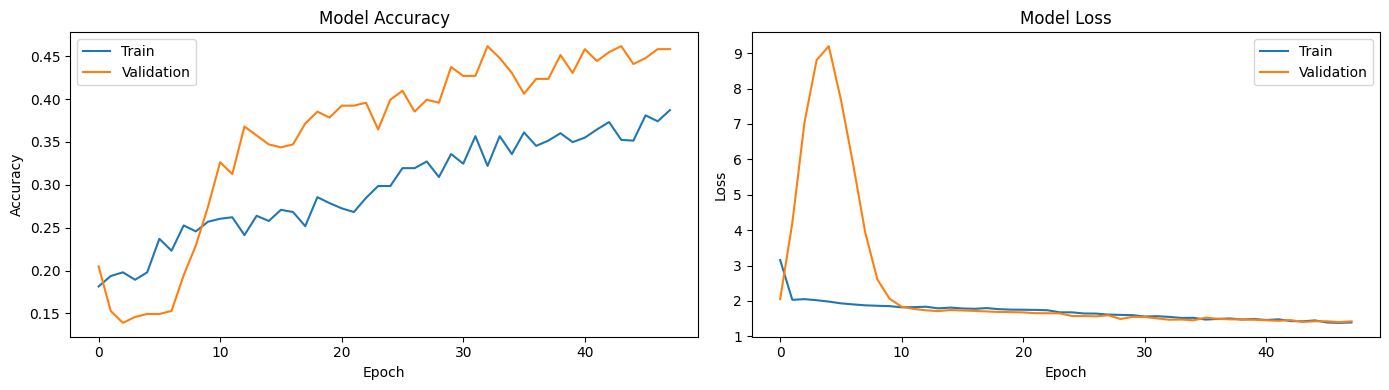

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step  


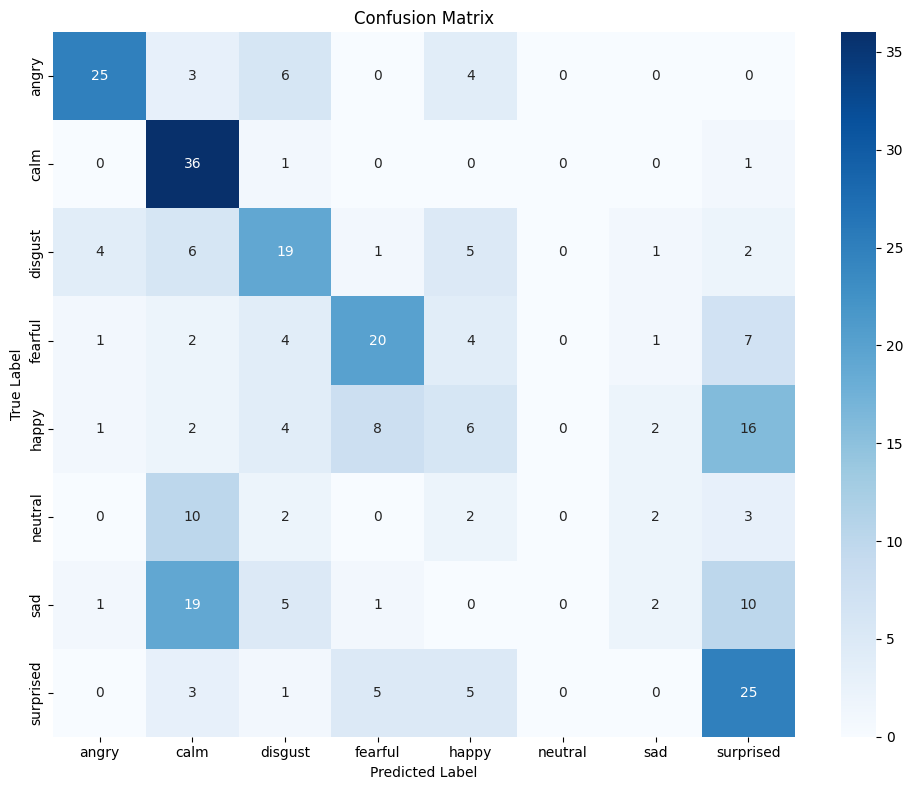

              precision    recall  f1-score   support

       angry       0.78      0.66      0.71        38
        calm       0.44      0.95      0.61        38
     disgust       0.45      0.50      0.47        38
     fearful       0.57      0.51      0.54        39
       happy       0.23      0.15      0.18        39
     neutral       0.00      0.00      0.00        19
         sad       0.25      0.05      0.09        38
   surprised       0.39      0.64      0.49        39

    accuracy                           0.46       288
   macro avg       0.39      0.43      0.39       288
weighted avg       0.42      0.46      0.41       288



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [24]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(history.history['accuracy'], label='Train')
ax1.plot(history.history['val_accuracy'], label='Validation')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

ax2.plot(history.history['loss'], label='Train')
ax2.plot(history.history['val_loss'], label='Validation')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.show()

# Confusion matrix
y_pred = model.predict(X_test_norm2)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# Per-class report
print(classification_report(y_true_classes, y_pred_classes, target_names=le.classes_))

In [25]:
# Save model
model.save('/content/drive/MyDrive/emotion_recognition_model.h5')

# Save the label encoder classes for later use
np.save('/content/drive/MyDrive/label_classes.npy', le.classes_)

# Save normalization parameters — needed to preprocess new audio the same way
np.save('/content/drive/MyDrive/norm_mean.npy', mean)
np.save('/content/drive/MyDrive/norm_std.npy', std)

print("Model and assets saved successfully.")

Model and assets saved successfully.
